# CRAFT Stage 1 (SPLADE) Pipeline
This notebook runs stage 1 with configurable dataset, corpus fields, and query type.

In [ ]:
import sys
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "6"
os.environ['HF_HOME'] = '/mnt/data2/asing725_2/hf_cache'
# Set HF_TOKEN in your environment before running: export HF_TOKEN=hf_...

CACHE_DIR = '/mnt/data2/asing725_2/hf_cache'
from pathlib import Path

import torch
from tqdm.notebook import tqdm

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "utils").exists():
    if (REPO_ROOT / "CRAFT" / "utils").exists():
        REPO_ROOT = REPO_ROOT / "CRAFT"
    else:
        REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from utils.datasets import (
    load_nq_questions,
    load_ott_questions,
    load_nq_tables,
    load_ott_tables,
 )
from utils.corpus_builder import (
    build_corpus_texts,
    build_query_texts,
    normalize_corpus_fields,
 )
from utils.eval_metric import evaluate_recall
from utils.io_utils import load_pickle, read_jsonl, save_pickle, write_jsonl
from utils.splade_utils import (
    build_inverted_index,
    encode_texts_in_batches,
    load_splade_model,
    rank_queries,
    splade_encode,
 )

DATASET = "nq"  
CORPUS_FIELDS = "title+headers+desc+cells" 
QUERY_TYPE = "query+subquestion"  
MAX_QUESTIONS = None  

MODEL_ID = "naver/splade_v2_distil"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 966
SPARSE_TOP_K = 5000
STAGE1_TOP_K = 5000

DATA_DIR = REPO_ROOT / "datasets"
RESULTS_DIR = REPO_ROOT / "results" / "stage1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RECALL_KS = {
    "stage1": [1, 10, 50, 100, 500, 5000],
    "stage2": [1, 10, 50, 100, 500],
    "stage3": [1, 10, 50],
}

## Stage 0 - Load data and build corpus

In [2]:
corpus_key = normalize_corpus_fields(CORPUS_FIELDS)
if "description" in QUERY_TYPE:
    query_key = "query_subquestion_description"
else:
    query_key = "query" if QUERY_TYPE == "query" else "query_subquestion"

if DATASET == "nq":
    questions = load_nq_questions(
        DATA_DIR / "NQ_Tables" / "interactions" / "combined.jsonl",
        max_questions=MAX_QUESTIONS,
    )
    tables = load_nq_tables(
        DATA_DIR / "NQ_Tables" / "tables" / "tables.jsonl",
        DATA_DIR / "nq_table_summary_table_description.jsonl",
    )
elif DATASET == "ottqa":
    questions = load_ott_questions(
        DATA_DIR / "OTT-QA" / "released_data" / "dev.json",
        max_questions=MAX_QUESTIONS,
    )
    tables = load_ott_tables(DATA_DIR / "OTT-QA" / "data" / "traindev_tables.json")
else:
    raise ValueError("Unknown dataset: use 'nq' or 'ottqa'")

corpus_path = RESULTS_DIR / f"{DATASET}_{corpus_key}_corpus.pkl"

if corpus_path.exists():
    corpus_payload = load_pickle(corpus_path)
    corpus_texts = corpus_payload["corpus_texts"]
    table_ids = corpus_payload["table_ids"]
else:
    corpus_texts, table_ids = build_corpus_texts(
        dataset=DATASET,
        tables=tables,
        corpus_fields=CORPUS_FIELDS,
    )
    save_pickle(corpus_path, {"corpus_texts": corpus_texts, "table_ids": table_ids})

print("Corpus example:")
print(corpus_texts[0])
print("Tables:", len(table_ids))
print("Questions:", len(questions))

Corpus example:
Lesley Joseph Born Residence Occupation Years active Height Television Children This table presents biographical information on Lesley Joseph, a British broadcaster and actress. It details her birthdate and place (Cardiff, Wales), current residence (Hampstead, North London), occupation (Broadcaster, actress), years active in her profession (1969-present), height (5 ft 2 in or 1.57 m), notable television work ('Birds of a Feather'), and number of children (2). The table provides a concise overview of key aspects of Joseph's life and career. Note that the 'Born' and 'Residence' fields contain multiple data points, providing a more complete picture of her life history. Lesley Joseph Joseph in Cardiff, Wales, May 2011 Lesley Diana Joseph 14 October 1945 (age 72) Finsbury Park, Haringey, London, England Hampstead, North London Broadcaster, actress 1969–present 5 ft 2 in (1.57 m) Birds of a Feather 2
Tables: 169898
Questions: 966


## Stage 0.5 - Build or load SPLADE index

In [3]:
# Download Model
# from huggingface_hub import snapshot_download
# snapshot_download(cache_dir=CACHE_DIR,repo_id=MODEL_ID)
MODEL_PATH = CACHE_DIR + "/models--naver--splade_v2_distil/snapshots/b5e5ebfb992c31a99ba3be148fb9d841f5c6d6a1/"
index_path = RESULTS_DIR / f"{DATASET}_{corpus_key}_splade_index.pkl"
tokenizer, model, device = load_splade_model(MODEL_ID, DEVICE)

if index_path.exists():
    index = load_pickle(index_path)
else:
    print("Precomputing Corpus Embedding")
    index = build_inverted_index(
        corpus_texts,
        tokenizer=tokenizer,
        model=model,
        batch_size=BATCH_SIZE,
        top_k=SPARSE_TOP_K,
        device=device,
        model_id=MODEL_PATH
    )
    save_pickle(index_path, index)

print("Index terms:", len(index))

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Model Loaded.
Index terms: 28385


## Stage 1 - Retrieve top-k tables

In [4]:
results_path = RESULTS_DIR / f"{DATASET}_stage1.jsonl"

if results_path.exists():
    results = list(read_jsonl(results_path))
    processed_qids = {item["qid"] for item in results}
else:
    results = []
    processed_qids = set()

pending_questions = [item for item in questions if item["qid"] not in processed_qids]

if pending_questions:
    query_texts = build_query_texts(pending_questions, query_type=QUERY_TYPE)
    query_vectors = []
    for i in tqdm(range(0, len(query_texts), BATCH_SIZE), desc="Encoding queries", unit="batch"):
        batch = query_texts[i : i + BATCH_SIZE]
        query_vectors.extend(
            splade_encode(
                batch,
                tokenizer=tokenizer,
                model=model,
                top_k=SPARSE_TOP_K,
                device=device,
            )
        )
    ranked_lists = rank_queries(index, query_vectors, top_k=STAGE1_TOP_K)

    for item, ranked in zip(pending_questions, ranked_lists):
        retrieved = [
            {"rank": rank + 1, "table_id": table_ids[doc_id], "score": float(score)}
            for rank, (doc_id, score) in enumerate(ranked)
        ]
        results.append(
            {
                "qid": item["qid"],
                "question": item["question"],
                "gold_table_ids": item["gold_table_ids"],
                "retrieved": retrieved,
            }
        )
    write_jsonl(results_path, results)

print("Saved:", results_path)

Encoding queries:   0%|          | 0/1 [00:00<?, ?batch/s]

Saved: /mnt/data1/asing725/ACL/CRAFT/results/stage1/nq_stage1.jsonl


## Stage 1 - Evaluate recall

Recall (all queries):
Recall@1: 0.31780538
Recall@10: 0.71428571
Recall@50: 0.90269151
Recall@100: 0.94824017
Recall@500: 0.98550725
Recall@5000: 0.99482402
Queries (all): 966

Recall (deduplicated by question, keeping best):
Recall@1: 0.33297062
Recall@10: 0.73014146
Recall@50: 0.91186072
Recall@100: 0.95321001
Recall@500: 0.99020675
Recall@5000: 0.99782372
Queries (dedup): 919

Recall summary (filtered to this dataset + corpus_key):


,dataset,corpus_key,query_key,query_type,corpus_fields,deduped,num_queries,recall@1,recall@10,recall@50,recall@100,recall@500,recall@5000
0,nq,title+headers+description+cells,query_subquestion,query+subquestion,title+headers+desc+cells,False,966,0.317805,0.714286,0.902692,0.94824,0.985507,0.994824
2,nq,title+headers+description+cells,query_subquestion,query+subquestion,title+headers+desc+cells,False,966,0.317805,0.714286,0.902692,0.94824,0.985507,0.994824
1,nq,title+headers+description+cells,query_subquestion,query+subquestion,title+headers+desc+cells,True,919,0.332971,0.730141,0.911861,0.95321,0.990207,0.997824
3,nq,title+headers+description+cells,query_subquestion,query+subquestion,title+headers+desc+cells,True,919,0.332971,0.730141,0.911861,0.95321,0.990207,0.997824


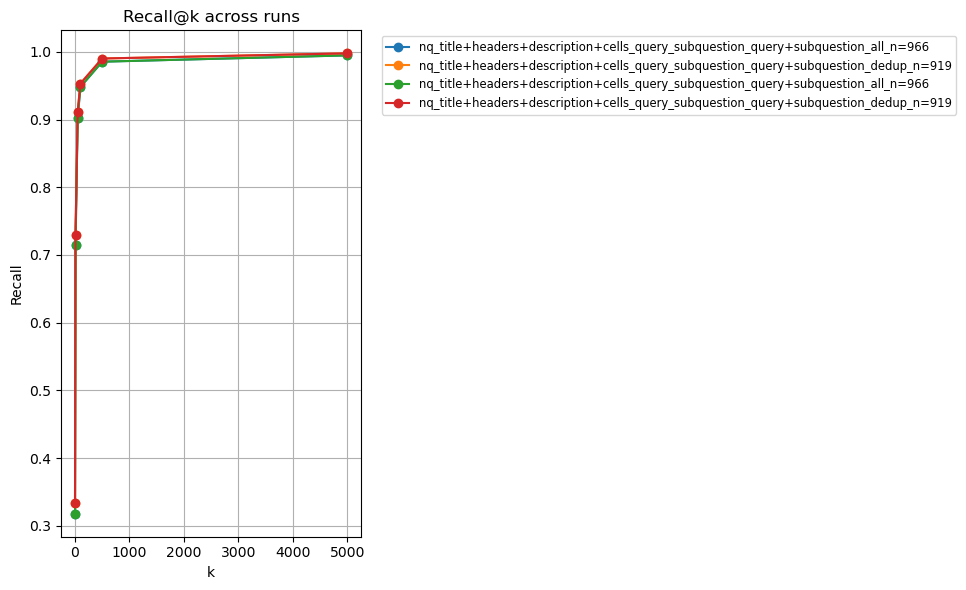

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display

ks = RECALL_KS["stage1"]

# Full metrics
metrics_all = evaluate_recall(results, ks)
print("Recall (all queries):")
for k in sorted(metrics_all):
    print(f"Recall@{k}: {metrics_all[k]:.8f}")
print(f"Queries (all): {len(results)}")

def _get_retrieved_ids(item):
    retrieved = item.get("retrieved", [])
    if retrieved and isinstance(retrieved[0], dict):
        return [r.get("table_id") for r in retrieved]
    return list(retrieved)

def _gold_rank(item):
    ids = _get_retrieved_ids(item)
    golds = item.get("gold_table_ids", [])
    for idx, tid in enumerate(ids, start=1):
        if tid in golds:
            return idx
    return float("inf")

# Deduplicate by original question text, keep item with minimum gold rank
best_per_question = {}
for item in results:
    qtext = (item.get("question") or "").strip()
    rank = _gold_rank(item)
    if qtext not in best_per_question or rank < best_per_question[qtext][0]:
        best_per_question[qtext] = (rank, item)
dedup_results = [v[1] for v in best_per_question.values()]

metrics_dedup = evaluate_recall(dedup_results, ks)
print("\nRecall (deduplicated by question, keeping best):")
for k in sorted(metrics_dedup):
    print(f"Recall@{k}: {metrics_dedup[k]:.8f}")
print(f"Queries (dedup): {len(dedup_results)}")

# Build summary rows for persistence
rows = []
for label, lst in (("all", results), ("dedup", dedup_results)):
    m = evaluate_recall(lst, ks)
    row = {
        "dataset": DATASET,
        "corpus_key": corpus_key,
        "query_key": query_key,
        "query_type": QUERY_TYPE,
        "corpus_fields": CORPUS_FIELDS,
        "deduped": (label == "dedup"),
        "num_queries": len(lst),
    }
    for k in ks:
        row[f"recall@{k}"] = m[k]
    rows.append(row)

summary_path = RESULTS_DIR / "recall_summary.csv"
new_df = pd.DataFrame(rows)
if summary_path.exists():
    df = pd.read_csv(summary_path)
    df = pd.concat([df, new_df], ignore_index=True)
else:
    df = new_df
df.to_csv(summary_path, index=False)

# Display a small table for this dataset/corpus_key
display_df = df[(df['dataset'] == DATASET) & (df['corpus_key'] == corpus_key)] if 'corpus_key' in df.columns else df
print("\nRecall summary (filtered to this dataset + corpus_key):")
display(display_df.sort_values(['deduped']))

# Plot recall@k across all saved runs
recall_cols = sorted([c for c in df.columns if c.startswith('recall@')], key=lambda x: int(x.split('@')[1]))
xs = [int(c.split('@')[1]) for c in recall_cols]
plt.figure(figsize=(10, 6))
for _, row in df.iterrows():
    label = f"{row.get('dataset')}_{row.get('corpus_key')}_{row.get('query_key')}_{row.get('query_type')}_{'dedup' if str(row.get('deduped')).lower() in ('true','1') else 'all'}_n={int(row.get('num_queries'))}"
    ys = [row[c] for c in recall_cols]
    plt.plot(xs, ys, marker='o', label=label)
plt.xlabel('k')
plt.ylabel('Recall')
plt.title('Recall@k across runs')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()